In [1]:
import utils
import xarray as xr
import numpy as np
import dask
from distributed import Client
from dask.distributed import wait
from ncar_jobqueue import NCARCluster
from glob import glob
import intake
import importlib
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
xr.set_options(keep_attrs=True)

## Spin up DASK cluster

In [2]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='100 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=100GB',
        project='NCGD0011',
        walltime='08:00:00',
        interface='ext',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [3]:
cluster, client = get_ClusterClient()
cluster.scale(20) 
client

Client Scheduler: tcp://128.117.208.186:44625 Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,Cluster Workers: 0 Cores: 0 Memory: 0 B


### Load the Data Catalog

In [4]:
catalog = intake.open_esm_datastore(
    '/glade/collections/cmip/catalog/intake-esm-datastore/catalogs/glade-cesm2-le.json'
)

### Get the historical data

In [5]:
subset = catalog.search(component='atm',
                        variable='TREFHT',
                        experiment='historical',
                        forcing_variant='cmip6',
                       )
with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    dsets = subset.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.stream.forcing_variant.variable'


In [6]:
%%time
# load historical
ds_hist = dsets['atm.historical.cam.h0.cmip6.TREFHT']
ds_hist

CPU times: user 8 µs, sys: 0 ns, total: 8 µs
Wall time: 11.2 µs


<xarray.Dataset>
Dimensions:       (ilev: 33, lat: 192, lev: 32, lon: 288, member_id: 50, nbnd: 2, time: 1980, zlon: 1)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * zlon          (zlon) float64 0.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) object 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
  * member_id     (member_id) <U12 'r10i1181p1f1' ... 'r9i1301p1f1'
Dimensions without coordinates: nbnd
Data variables: (12/27)
    zlon_bnds     (zlon, nbnd) float64 dask.array<chunksize=(1, 2), meta=np.ndarray>
    gw            (lat) float64 dask.array<chunksize=(192,), meta=np.ndarray>
    hyam          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    hybm          (lev) float64 dask.array<chunksize=(32,), meta=np.ndarray>
    P0            float64 ...
    hyai          (ilev) float64 dask.array<chunksize=(33,), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    f11vmr        (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    f12vmr        (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    sol_tsi       (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    nsteph        (time) float64 dask.array<chunksize=(120,), meta=np.ndarray>
    TREFHT        (member_id, time, lat, lon) float32 dask.array<chunksize=(1, 120, 192, 288), meta=np.ndarray>
Attributes:
    time_period_freq:        month_1
    topography_file:         /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/f...
    source:                  CAM
    NCO:                     netCDF Operators version 4.9.4 (Homepage = http:...
    intake_esm_varname:      ['TREFHT']
    model_doi_url:           https://doi.org/10.5065/D67H1H0V
    Conventions:             CF-1.0
    history:                 Wed Aug 25 23:43:08 2021: ncea -d time,1,120 ./b...
    logname:                 sunseon
    intake_esm_dataset_key:  atm.historical.cam.h0.cmip6.TREFHT

### Load future data

In [7]:
%%time
subset = catalog.search(component='atm',
                        variable='TREFHT',
                        experiment='ssp370',
                        forcing_variant='cmip6',
                       )
with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    dsets = subset.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.stream.forcing_variant.variable'


CPU times: user 17.9 s, sys: 284 ms, total: 18.2 s
Wall time: 27.2 s


In [8]:
dsets.keys()

dict_keys(['atm.ssp370.cam.h0.cmip6.TREFHT', 'atm.ssp370.cam.h1.cmip6.TREFHT'])

In [9]:
ds_ssp = dsets['atm.ssp370.cam.h0.cmip6.TREFHT']

## Concatenate historical and future datasets, keep just years of interest

In [10]:
ds = xr.concat((ds_hist, ds_ssp),dim='time')
ds.time

<xarray.DataArray 'time' (time: 3012)>
array([cftime.DatetimeNoLeap(1850, 2, 1, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(1850, 3, 1, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(1850, 4, 1, 0, 0, 0, 0), ...,
       cftime.DatetimeNoLeap(2100, 11, 1, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(2100, 12, 1, 0, 0, 0, 0),
       cftime.DatetimeNoLeap(2101, 1, 1, 0, 0, 0, 0)], dtype=object)
Coordinates:
  * time     (time) object 1850-02-01 00:00:00 ... 2101-01-01 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds

In [11]:
ds.time_bnds

<xarray.DataArray 'time_bnds' (time: 3012, nbnd: 2)>
dask.array<concatenate, shape=(3012, 2), dtype=object, chunksize=(120, 2), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1850-02-01 00:00:00 ... 2101-01-01 00:00:00
Dimensions without coordinates: nbnd
Attributes:
    long_name:  time interval endpoints

In [12]:
ds['time'] = ds.time_bnds.compute().mean(dim="nbnd")

### Compute annual means and write out the data

In [13]:
%%time
######## make annual mean

ds_ann = ds.resample({'time':'A'}).mean(dim='time').compute()

CPU times: user 25.7 s, sys: 2.2 s, total: 28 s
Wall time: 36.3 s


In [14]:
ds_ann

<xarray.Dataset>
Dimensions:    (ilev: 33, lat: 192, lev: 32, lon: 288, member_id: 50, nbnd: 2, time: 251, zlon: 1)
Coordinates:
  * time       (time) object 1850-12-31 00:00:00 ... 2100-12-31 00:00:00
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * zlon       (zlon) float64 0.0
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev        (lev) float64 3.643 7.595 14.36 24.61 ... 936.2 957.5 976.3 992.6
  * ilev       (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * member_id  (member_id) <U12 'r10i1181p1f1' 'r10i1231p1f1' ... 'r9i1301p1f1'
Dimensions without coordinates: nbnd
Data variables: (12/24)
    zlon_bnds  (time, zlon, nbnd) float64 0.0 358.8 0.0 ... 358.8 0.0 358.8
    gw         (time, lat) float64 3.382e-05 0.0002705 ... 0.0002705 3.382e-05
    hyam       (time, lev) float64 0.003643 0.007595 0.01436 ... 0.001989 0.0
    hybm       (time, lev) float64 0.0 0.0 0.0 0.0 ... 0.9512 0.9743 0.9926
    P0         (time) float64 1e+05 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai       (time, ilev) float64 0.002255 0.005032 0.01016 ... 0.0 0.0
    ...         ...
    n2ovmr     (time) float64 2.73e-07 2.731e-07 ... 4.206e-07 4.219e-07
    f11vmr     (time) float64 3.211e-11 3.211e-11 ... 1.076e-09 1.082e-09
    f12vmr     (time) float64 0.0 0.0 0.0 0.0 ... 2.163e-10 2.139e-10 2.115e-10
    sol_tsi    (time) float64 -1.0 -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
    nsteph     (time) float64 9.452e+03 2.697e+04 ... 1.481e+06 1.499e+06
    TREFHT     (time, member_id, lat, lon) float32 226.0 226.0 ... 268.0 268.0
Attributes:
    time_period_freq:        month_1
    topography_file:         /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/f...
    source:                  CAM
    NCO:                     netCDF Operators version 4.9.4 (Homepage = http:...
    intake_esm_varname:      ['TREFHT']
    model_doi_url:           https://doi.org/10.5065/D67H1H0V
    Conventions:             CF-1.0
    history:                 Wed Aug 25 23:43:08 2021: ncea -d time,1,120 ./b...
    logname:                 sunseon
    intake_esm_dataset_key:  atm.historical.cam.h0.cmip6.TREFHT

In [15]:
# Export the dataset to NetCDF with all attributes and coordinates
ds_ann.to_netcdf('/glade/derecho/scratch/kristenk/ToE_saved_data/TREFHT_annual_means_1850-2100.nc', mode='w')

## ToE ANALYSIS

In [16]:
ds_ann['time'] = np.arange(1850,2101,1)

In [17]:
time3d = np.full([251,192,288],1,dtype=int)

ylen = 192
xlen = 288

for x in np.arange(0,xlen,1):
    for y in np.arange(0,ylen,1):

        time3d[:,y,x]=ds_ann.time.values

time3d = xr.DataArray(time3d,dims=('time','lat','lon'))

In [29]:
%%time

#HISTORICAL PERIOD = 1850 - 1899 (50 years)

upthres_ds = xr.Dataset()
lothres_ds = xr.Dataset()

variables=['TREFHT']

for var in variables:
    
    ### calculate                                                                                                                                                                                                                                                                 
    mean_var = ds_ann[var].isel(time=slice(0,50)).mean(dim=('time','member_id'))
    std_var = ds_ann[var].isel(time=slice(0,50)).std(dim=('time','member_id'))
    
    var_array_upthres = mean_var + 2 * std_var
    var_array_lothres = mean_var - 2 * std_var

    upthres_ds[var] = var_array_upthres
    lothres_ds[var] = var_array_lothres

CPU times: user 460 ms, sys: 145 ms, total: 605 ms
Wall time: 639 ms


In [30]:
ToE_up = time3d.where(ds_ann.TREFHT.mean(dim='member_id') > upthres_ds['TREFHT'])
ToE_up = ToE_up.min(dim='time')

In [31]:
ToE_down = time3d.where(ds_ann.TREFHT.mean(dim='member_id') < lothres_ds['TREFHT'])
ToE_down = ToE_down.min(dim='time')

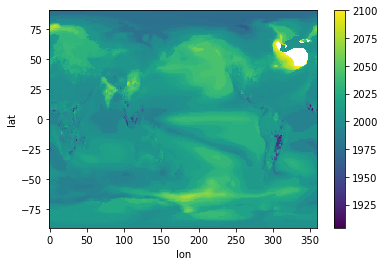

In [32]:
ToE_up.plot()

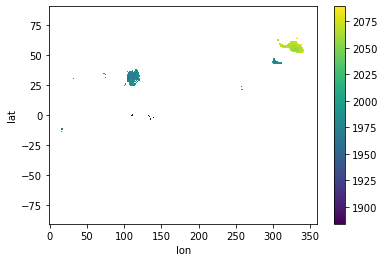

In [33]:
ToE_down.plot()

### Make a map of the ToE times

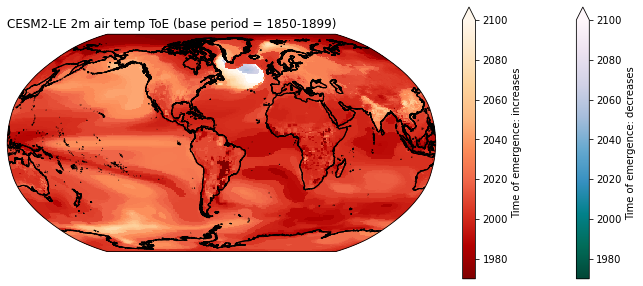

In [34]:
fig = plt.figure(figsize=(12,5))

############### 
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson(central_longitude=305.0))
#ax.set_extent([-180, 180, -90, -30], ccrs.PlateCarree())
ax.set_title('CESM2-LE 2m air temp ToE (base period = 1850-1899)', loc='left')

pc = ax.pcolormesh(ds_ann.lon,ds_ann.lat,ToE_down,
                    transform=ccrs.PlateCarree(),cmap='PuBuGn_r',
                   vmin=1970,vmax=2100)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='max', label='Time of emergence: decreases');

pc = ax.pcolormesh(ds_ann.lon,ds_ann.lat,ToE_up,
                    transform=ccrs.PlateCarree(),cmap='OrRd_r',
                   vmin=1970,vmax=2100)


ax.coastlines('10m',linewidth=1)
fig.colorbar(pc,extend='max', label='Time of emergence: increases');

fig.savefig('/glade/work/kristenk/figs/CESM2-LE-ToE-AirTemp2m.png', bbox_inches='tight', dpi=300, format='png');

### Get area for making area-weight average

In [35]:
subset = catalog.search(component='atm',variable=['AREA'],experiment=['historical'],member_id=['r10i1191p1f2'])

In [36]:
with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    dsets2 = subset.to_dataset_dict()


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.stream.forcing_variant.variable'


In [37]:
area = dsets2['atm.historical.cam.h0.smbb.AREA'].AREA.isel(time=0).squeeze()

### Make plot of global 2m air temp (area-weighted)

In [39]:
glb_2m_air_temp = (ds_ann.TREFHT * area).sum(dim=('lon','lat')) / area.sum(dim=('lon','lat'))

In [46]:
glb_2m_air_temp = glb_2m_air_temp.load()

Text(0.5, 0, 'Year')

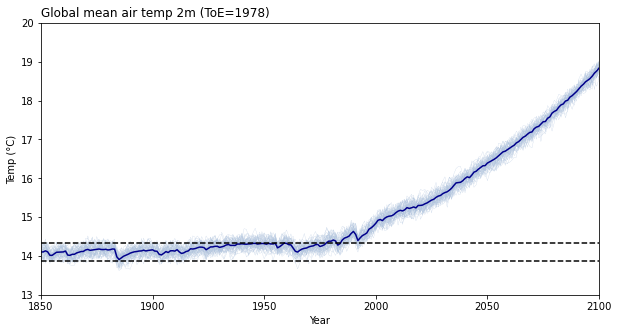

In [68]:
fig = plt.figure(figsize=(10,5))

#################
ax = fig.add_subplot(1, 1, 1)
ax.set_title("Global mean air temp 2m (ToE=1978)", loc="left", fontsize=12)

for mem in np.arange(0,50,1):

    ax.plot(glb_2m_air_temp.time, glb_2m_air_temp.isel(member_id=mem)-273.15, color='lightsteelblue',linewidth=0.2)
    
ax.plot(glb_2m_air_temp.time, glb_2m_air_temp.mean(dim='member_id')-273.15,
           color='darkblue', zorder=2)
std_up = (glb_2m_air_temp.mean(dim='member_id').isel(time=slice(0,50)).mean(dim='time') + 2*glb_2m_air_temp.std(dim='member_id').isel(time=slice(0,50)).mean(dim='time')-273.15)
std_down = (glb_2m_air_temp.mean(dim='member_id').isel(time=slice(0,50)).mean(dim='time') - 2*glb_2m_air_temp.std(dim='member_id').isel(time=slice(0,50)).mean(dim='time')-273.15)
ax.axhline(std_up, linestyle='--',color='black')
ax.axhline(std_down, linestyle='--',color='black')
ax.set_xlim(1850,2100)
ax.set_ylim(13,20)
ax.set_ylabel('Temp (°C)')
ax.set_xlabel('Year')

In [66]:
ToE_glb = glb_2m_air_temp.time.where(glb_2m_air_temp.mean(dim='member_id')-273.15>std_up).min(dim='time')

In [67]:
ToE_glb

<xarray.DataArray 'time' ()>
array(1978.)

### Get data ready for writing out

In [75]:
ds_out = xr.Dataset()

ds_out['Air_temp_2m_ens_mean'] = ds_ann['TREFHT'].mean(dim='member_id') - 273.15
ds_out['Air_temp_2m_ens_mean'].attrs = ds_ann.TREFHT.attrs
ds_out['Air_temp_2m_ens_mean'].attrs['units'] = 'deg C'
ds_out['Air_temp_2m_ens_mean'].attrs['notes'] = 'ensemble mean of 50 cmip6 forcing ensemble members'

ds_out['Air_temp_2m_st_dev'] = ds_ann['TREFHT'].std(dim='member_id')
ds_out['Air_temp_2m_st_dev'].attrs = ds_ann.TREFHT.attrs
ds_out['Air_temp_2m_st_dev'].attrs['units'] = 'deg C'
ds_out['Air_temp_2m_st_dev'].attrs['notes'] = 'ensemble standard deviation of 50 cmip6 forcing ensemble members'

ds_out.attrs['author'] = 'Kristen Krumhardt'
ds_out.attrs['date_processed'] = datetime.now().strftime('%Y-%m-%d')
ds_out.attrs['contents'] = f'Reference height 2m air temperature from CESM2-LE'

ds_out

<xarray.Dataset>
Dimensions:               (lat: 192, lon: 288, time: 251)
Coordinates:
  * time                  (time) int64 1850 1851 1852 1853 ... 2098 2099 2100
  * lat                   (lat) float64 -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon                   (lon) float64 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
Data variables:
    Air_temp_2m_ens_mean  (time, lat, lon) float32 -48.09 -48.09 ... -4.769
    Air_temp_2m_st_dev    (time, lat, lon) float32 0.681 0.681 ... 0.8148 0.8148
Attributes:
    author:          Kristen Krumhardt
    date_processed:  2026-06-22
    contents:        Reference height 2m air temperature from CESM2-LE

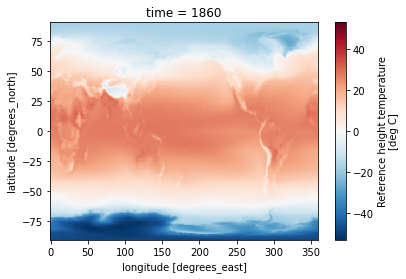

In [76]:
ds_out['Air_temp_2m_ens_mean'].isel(time=10).plot()

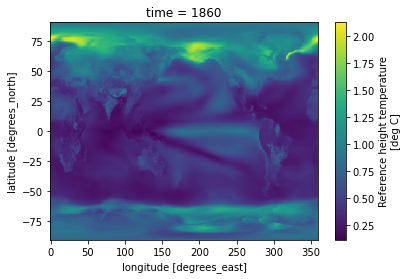

In [77]:
ds_out['Air_temp_2m_st_dev'].isel(time=10).plot()

In [78]:
# calculate the size of the dataset in GB
size_gb = ds_out.nbytes / (1024**3)
print(f"The dataset is approximately {size_gb:.2f} GB.")

The dataset is approximately 0.10 GB.


In [80]:
path_out = '/glade/derecho/scratch/kristenk/ToE_saved_data/'
file_out = 'CESM2-LE-2mTemp_ens_mean_std.nc'
fout = path_out + file_out

In [81]:
# Export the dataset to NetCDF with all attributes and coordinates
ds_out.to_netcdf(fout)

In [82]:
fout

'/glade/derecho/scratch/kristenk/ToE_saved_data/CESM2-LE-2mTemp_ens_mean_std.nc'